In [1]:
import matplotlib.pyplot as plt
import numpy as np
import stellarator as stl
import spline as sp
import importlib
import plotly.graph_objects as go

In [2]:
case_path = '/home/emgreen/brezzelator/'
fname="/spdata.dat"
(sgn,psiw,ped,spdtheta,spdpsi,lsp,lst,torpsi,qpsi,gpsi,cpsi,rpsi,ntor,bcn,bsn,xcn,xsn,zcn,zsn,fcn,fsn,ndim,ndim_total,r0,b0,nfp) =stl.read_spdata(case_path+fname,0,9)

GTC numerical equilibrium model #3
[128, 199]
[0.018469331568]
[24, 3]
VMEC DIMENSION READ:
lsp= 128 lst= 200 ndim_total= 24 psiw= 0.018469331568
In zeta out system: sgn(psip)= 1 torpsi(1,lsp)= -0.0025038023265 gpsi(1,1)= -59.823851231 fielddir= 1
Using VMEC: R0= 0.18983897643230002 B0= 119.18254952150001 ndim= 24


Completed mapping to boozer coordinates
begin constructing spline
Completed mapping to boozer coordinates
begin constructing spline
Completed mapping to boozer coordinates
begin constructing spline
Completed mapping to boozer coordinates
begin constructing spline


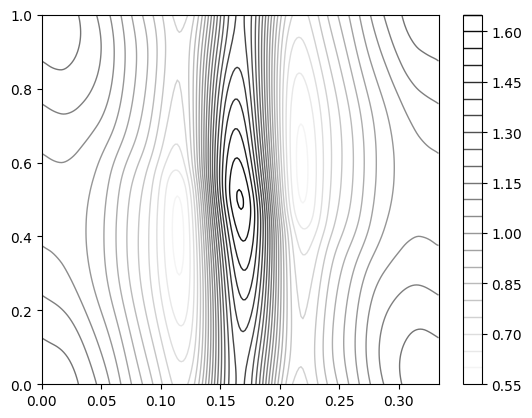

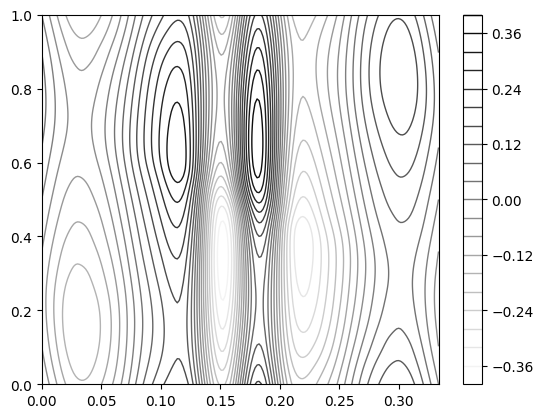

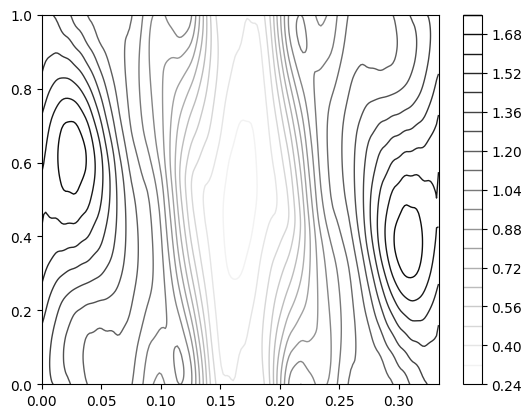

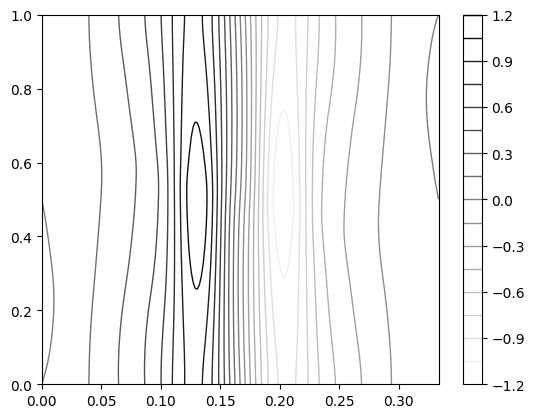

In [3]:
qpsi_sp = sp.mk_splinefunction(lsp,spdpsi,qpsi,0)
rpsi_sp = sp.mk_splinefunction(lsp,spdpsi,rpsi,1)
qpsi_sp(psiw*0.5)
nzsp_sec=65
mtoroidal=1
lszeta=mtoroidal*nzsp_sec+1
toroidaln=nfp
spdzeta = 2*np.pi/toroidaln/(lszeta-1)
#ndim=14
noaxis=1
#ndim_total=14
#Each of these will take a while
spx3d,spx=stl.construct_3d_spline(sgn,psiw,ntor,lsp,lst,lszeta,toroidaln,ndim,noaxis,ndim_total,xcn,xsn)
spz3d,spz=stl.construct_3d_spline(sgn,psiw,ntor,lsp,lst,lszeta,toroidaln,ndim,noaxis,ndim_total,zcn,zsn)
spb3d,spb=stl.construct_3d_spline(sgn,psiw,ntor,lsp,lst,lszeta,toroidaln,ndim,noaxis,ndim_total,bcn,bsn)
spf3d,spf=stl.construct_3d_spline(sgn,psiw,ntor,lsp,lst,lszeta,toroidaln,ndim,noaxis,ndim_total,fcn,fsn)

sp.contour_sp(spx,toroidaln,psiw)
plt.show()
sp.contour_sp(spz,toroidaln,psiw)
plt.show()
sp.contour_sp(spb,toroidaln,psiw)
plt.show()
sp.contour_sp(spf,toroidaln,psiw)
plt.show()


In [4]:
def cartesian_boozer(psi,theta,zeta,nfp = 1):
    #returns cartesian coordinates of point in boozer coordinates
    #requires all 4 3d sspline functions
    r = spx(psi,theta,zeta%(2*np.pi/nfp))
    z = spz(psi,theta,zeta%(2*np.pi/nfp))
    f = -spf(psi,theta,zeta%(2*np.pi/nfp))-zeta%(2*np.pi/nfp)
    x = r*np.cos(f-2*np.pi/nfp*int(zeta/(2*np.pi/nfp)))
    y = r*np.sin(f-2*np.pi/nfp*int(zeta/(2*np.pi/nfp)))
    return x,y,z

# Define your grid for theta and zeta
theta_vals = np.linspace(0, 2*np.pi, 100)
zeta_vals = np.linspace(0,  2*np.pi, 200)
theta, zeta = np.meshgrid(theta_vals, zeta_vals)

# Fixed psi value
psi = psiw*0.8  # Example constant psi

# Flatten the meshgrid arrays for easier computation
theta_flat = theta.flatten()
zeta_flat = zeta.flatten()

x = np.zeros(len(theta_flat))
y = np.zeros(len(theta_flat))
z = np.zeros(len(theta_flat))
b_field = np.zeros(len(theta_flat))
# Convert to Cartesian coordinates
for i in range(len(theta_flat)):
    x[i], y[i], z[i] = cartesian_boozer(psi, theta_flat[i], zeta_flat[i],toroidaln)
    b_field[i] = spb(psi, theta_flat[i], zeta_flat[i]%(2*np.pi/toroidaln))

# Reshape arrays back to grid for plotting
x = x.reshape(theta.shape)
y = y.reshape(theta.shape)
z = z.reshape(theta.shape)
b_field = b_field.reshape(theta.shape)

fig = go.Figure()
# Create a Plotly surface plot
# Add each layer as a surface to the same figure, with varying opacity
fig.add_trace(go.Surface(
    x=x, y=y, z=z, surfacecolor=b_field,
    opacity=1,
    colorscale='Viridis',
    showscale=False  # Disable the color bar for all layers except one if desired
))


x_line = np.zeros(len(zeta_vals))
y_line = np.zeros(len(zeta_vals))
z_line = np.zeros(len(zeta_vals))
for i in range(len(zeta_vals)):
    x_line[i], y_line[i], z_line[i] = cartesian_boozer(psi, 0.0, zeta_vals[i], toroidaln)

fig.add_trace(go.Scatter3d(x=x_line, y=y_line, z=z_line, mode='lines', line=dict(color='black', width=3)))
# Customize layout for better visualization
fig.update_layout(scene=dict(
    xaxis_title="X",
    yaxis_title="Y",
    zaxis_title="Z",
    aspectmode='data'  # use data scale so 1 unit is same length on all axes
))
bfig1 = fig
fig.show()